### Setup & Imports

In [1]:
# SETUP & IMPORTS

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# Set working directory to your project folder 
# This means all file paths below work as relative paths (data/..., export/...)
os.chdir(r'C:\Users\elitebook folio\Documents\EDWARD PROJECTS\food_bank_poverty_canada')

# Visual style
# 'whitegrid' gives clean white background with faint grid lines
# palette 'colorblind' is accessible for all audiences including PhD reviewers
sns.set_theme(style='whitegrid', palette='colorblind', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150          # High-resolution figures
plt.rcParams['savefig.bbox'] = 'tight'    # No clipping when saving

print("✅ Setup complete. Working directory:", os.getcwd())

✅ Setup complete. Working directory: C:\Users\elitebook folio\Documents\EDWARD PROJECTS\food_bank_poverty_canada


### Load & Clean the Provincial Census Data

In [4]:
# LOAD & CLEAN CENSUS PROVINCE DATA 

# Step 1: Load the file 
df_prov_raw = pd.read_csv('data/census_province_2021.csv', encoding='latin-1')
print(f"Loaded: {df_prov_raw.shape[0]:,} rows × {df_prov_raw.shape[1]} columns")

# tep 2: Strip ALL leading/trailing whitespace from characteristic names 
# This is the root cause — the census file uses indentation (spaces) to show
# hierarchy. Stripping removes them so matching works reliably.
df_prov_raw['CHARACTERISTIC_NAME'] = df_prov_raw['CHARACTERISTIC_NAME'].str.strip()

# Step 3: Filter to provinces + Canada only
df_prov_raw = df_prov_raw[
    df_prov_raw['GEO_LEVEL'].isin(['Province', 'Country'])
].copy()

print(f"After geography filter: {df_prov_raw.shape[0]:,} rows")

# Step 4: Define indicators — NO leading spaces needed after strip 
indicators = {
    'Unemployment rate':
        'unemployment_rate',

    'Prevalence of low income based on the Low-income measure, after tax (LIM-AT) (%)':
        'lim_at_pct',

    'Median after-tax income of household in 2020 ($)':
        'median_aftertax_income',

    'Gini index on adjusted household after-tax income':
        'gini_aftertax',

    '% of tenant households spending 30% or more of its income on shelter costs':
        'tenant_shelter_burden_pct',

    'Prevalence of low income based on the Low-income cut-offs, after tax (LICO-AT) (%)':
        'lico_at_pct'
}

# Step 5: Filter to only indicator rows 
df_filtered = df_prov_raw[
    df_prov_raw['CHARACTERISTIC_NAME'].isin(indicators.keys())
].copy()

print(f"\nRows matched after indicator filter: {len(df_filtered)}")
print("Characteristics matched:")
print(df_filtered['CHARACTERISTIC_NAME'].unique())

# Step 6: Choose correct value column
df_filtered['value'] = np.where(
    df_filtered['CHARACTERISTIC_NAME'].isin([
        'Median after-tax income of household in 2020 ($)',
        'Gini index on adjusted household after-tax income'
    ]),
    df_filtered['C1_COUNT_TOTAL'],
    df_filtered['C10_RATE_TOTAL']
)

# Step 7: Map to clean column names
df_filtered['indicator'] = df_filtered['CHARACTERISTIC_NAME'].map(indicators)

# Step 8: Pivot to wide format
census_prov = df_filtered.pivot_table(
    index='GEO_NAME',
    columns='indicator',
    values='value',
    aggfunc='first'
).reset_index()

census_prov.columns.name = None
census_prov.rename(columns={'GEO_NAME': 'province'}, inplace=True)

# Step 9: Confirm
print("\n── census_prov columns:", list(census_prov.columns))
print("── Rows:", len(census_prov))
print("\nMissing values:")
print(census_prov.isnull().sum())
print("\nPreview:")
print(census_prov.head())

Loaded: 36,834 rows × 23 columns
After geography filter: 28,941 rows

Rows matched after indicator filter: 66
Characteristics matched:
['Median after-tax income of household in 2020 ($)'
 'Prevalence of low income based on the Low-income measure, after tax (LIM-AT) (%)'
 'Prevalence of low income based on the Low-income cut-offs, after tax (LICO-AT) (%)'
 'Gini index on adjusted household after-tax income'
 '% of tenant households spending 30% or more of its income on shelter costs'
 'Unemployment rate']

── census_prov columns: ['province', 'gini_aftertax', 'lico_at_pct', 'lim_at_pct', 'median_aftertax_income', 'tenant_shelter_burden_pct', 'unemployment_rate']
── Rows: 11

Missing values:
province                     0
gini_aftertax                0
lico_at_pct                  0
lim_at_pct                   0
median_aftertax_income       0
tenant_shelter_burden_pct    0
unemployment_rate            0
dtype: int64

Preview:
           province  gini_aftertax  lico_at_pct  lim_at_pct  

### Load & Clean the CMA Census Data

In [20]:
# CELL 3: LOAD AND CLEAN CENSUS CMA DATA (chunked for 66MB file)

print("Loading CMA census file in chunks. This may take 30 to 60 seconds...")

# Redefine indicators locally to guarantee no stale variable is inherited
# Keys have no leading spaces because stripping handles that inside the loop
indicators_cma = {
    'Unemployment rate':
        'unemployment_rate',

    'Prevalence of low income based on the Low-income measure, after tax (LIM-AT) (%)':
        'lim_at_pct',

    'Median after-tax income of household in 2020 ($)':
        'median_aftertax_income',

    'Gini index on adjusted household after-tax income':
        'gini_aftertax',

    '% of tenant households spending 30% or more of its income on shelter costs':
        'tenant_shelter_burden_pct',

    'Prevalence of low income based on the Low-income cut-offs, after tax (LICO-AT) (%)':
        'lico_at_pct'
}

# Step 1: Read in chunks and filter on the fly
# chunksize=50000 means pandas reads 50,000 rows at a time instead of all at once
# This prevents memory overload on a large file
chunks = []

for chunk in pd.read_csv(
    'data/census_cma_2021.csv',
    encoding='latin-1',
    chunksize=50_000
):
    # Strip ALL leading and trailing whitespace from characteristic names
    # The CMA census file uses indentation (spaces) to show data hierarchy
    # Stripping must happen BEFORE the isin() filter otherwise names never match
    chunk['CHARACTERISTIC_NAME'] = chunk['CHARACTERISTIC_NAME'].str.strip()

    # Keep only Census Metropolitan Area rows (not agglomerations or parts)
    # Keep only rows matching the 6 indicator names defined above
    filtered = chunk[
        (chunk['GEO_LEVEL'] == 'Census metropolitan area') &
        (chunk['CHARACTERISTIC_NAME'].isin(indicators_cma.keys()))
    ]
    if len(filtered) > 0:
        chunks.append(filtered)

df_cma_raw = pd.concat(chunks, ignore_index=True)
print(f"Extracted {df_cma_raw.shape[0]:,} rows across {df_cma_raw['GEO_NAME'].nunique()} CMAs")

# Step 2: Choose the correct value column for each indicator
# Dollar values and index values use C1_COUNT_TOTAL
# Rates and percentages use C10_RATE_TOTAL
df_cma_raw['value'] = np.where(
    df_cma_raw['CHARACTERISTIC_NAME'].isin([
        'Median after-tax income of household in 2020 ($)',
        'Gini index on adjusted household after-tax income'
    ]),
    df_cma_raw['C1_COUNT_TOTAL'],
    df_cma_raw['C10_RATE_TOTAL']
)

df_cma_raw['indicator'] = df_cma_raw['CHARACTERISTIC_NAME'].map(indicators_cma)

# Step 3: Pivot from long to wide format
# One row per city, one column per indicator
census_cma = df_cma_raw.pivot_table(
    index='GEO_NAME',
    columns='indicator',
    values='value',
    aggfunc='first'
).reset_index()

census_cma.columns.name = None
census_cma.rename(columns={'GEO_NAME': 'city'}, inplace=True)

# Step 4: Add a province abbreviation label to each CMA
# Useful for grouping and colouring charts by province later
province_map = {
    "St. John's": 'NL', 'Halifax': 'NS', 'Moncton': 'NB',
    'Saint John': 'NB', 'Fredericton': 'NB', 'Québec': 'QC',
    'Sherbrooke': 'QC', 'Trois-Rivières': 'QC', 'Drummondville': 'QC',
    'Saguenay': 'QC', 'Montréal': 'QC', 'Ottawa - Gatineau': 'ON/QC',
    'Kingston': 'ON', 'Belleville - Quinte West': 'ON', 'Peterborough': 'ON',
    'Oshawa': 'ON', 'Toronto': 'ON', 'Hamilton': 'ON',
    'St. Catharines - Niagara': 'ON', 'Kitchener - Cambridge - Waterloo': 'ON',
    'Brantford': 'ON', 'Guelph': 'ON', 'London': 'ON', 'Windsor': 'ON',
    'Barrie': 'ON', 'Greater Sudbury / Grand Sudbury': 'ON',
    'Thunder Bay': 'ON', 'Winnipeg': 'MB', 'Regina': 'SK',
    'Saskatoon': 'SK', 'Lethbridge': 'AB', 'Red Deer': 'AB',
    'Calgary': 'AB', 'Edmonton': 'AB', 'Kelowna': 'BC',
    'Kamloops': 'BC', 'Chilliwack': 'BC', 'Abbotsford - Mission': 'BC',
    'Vancouver': 'BC', 'Victoria': 'BC', 'Nanaimo': 'BC'
}
census_cma['province_abbr'] = census_cma['city'].map(province_map)

# Step 5: Confirm all 7 columns loaded correctly
print("\nCensus CMA Shape:", census_cma.shape)
print("\nColumn names:", list(census_cma.columns))
print("\nMissing values per column:")
print(census_cma.isnull().sum())
print("\nPreview:")
census_cma[['city', 'median_aftertax_income', 'unemployment_rate',
            'lim_at_pct', 'gini_aftertax', 'tenant_shelter_burden_pct']].head()

Loading CMA census file in chunks. This may take 30 to 60 seconds...
Extracted 246 rows across 41 CMAs

Census CMA Shape: (41, 8)

Column names: ['city', 'gini_aftertax', 'lico_at_pct', 'lim_at_pct', 'median_aftertax_income', 'tenant_shelter_burden_pct', 'unemployment_rate', 'province_abbr']

Missing values per column:
city                         0
gini_aftertax                0
lico_at_pct                  0
lim_at_pct                   0
median_aftertax_income       0
tenant_shelter_burden_pct    0
unemployment_rate            0
province_abbr                0
dtype: int64

Preview:


,city,median_aftertax_income,unemployment_rate,lim_at_pct,gini_aftertax,tenant_shelter_burden_pct
0,Abbotsford - Mission,82000.0,7.6,8.3,0.264,33.2
1,Barrie,85000.0,12.1,7.7,0.265,42.4
2,Belleville - Quinte West,69500.0,11.2,10.5,0.261,36.7
3,Brantford,76000.0,11.4,9.4,0.265,38.6
4,Calgary,87000.0,12.3,8.6,0.327,34.5


### Load & Clean the Food Insecurity Data

In [21]:
# LOAD & CLEAN FOOD INSECURITY DATA

# Step 1: Load with UTF-8-sig encoding to strip the BOM character
# BOM (Byte Order Mark) is an invisible character that corrupts the first
# column name. utf-8-sig strips it automatically.
df_fi_raw = pd.read_csv('data/food_insecurity_2018_2024.csv', encoding='utf-8-sig')

# Clean up column names: strip quotes and whitespace
df_fi_raw.columns = df_fi_raw.columns.str.strip().str.strip('"')
print("Columns:", list(df_fi_raw.columns))
print(f"Shape: {df_fi_raw.shape}")

# Step 2: Define the 10 provinces + Canada we want
# Exclude regional groupings like 'Atlantic provinces', 'Prairie provinces'
provinces_keep = [
    'Canada',
    'Newfoundland and Labrador', 'Prince Edward Island',
    'Nova Scotia', 'New Brunswick', 'Quebec', 'Ontario',
    'Manitoba', 'Saskatchewan', 'Alberta', 'British Columbia'
]

# Step 3: Build the 7-year trend table
# Filter: All persons | Total food insecure | Percentage | Provinces only
fi_trend = df_fi_raw[
    (df_fi_raw['GEO'].isin(provinces_keep)) &
    (df_fi_raw['Demographic characteristics'] == 'All persons') &
    (df_fi_raw['Household food security status'] == 'Food insecure') &
    (df_fi_raw['Statistics'] == 'Percentage of persons')
][['REF_DATE', 'GEO', 'VALUE', 'STATUS']].copy()

fi_trend.rename(columns={
    'REF_DATE': 'year',
    'GEO': 'province',
    'VALUE': 'food_insecurity_pct',
    'STATUS': 'reliability'
}, inplace=True)

fi_trend = fi_trend.sort_values(['province', 'year']).reset_index(drop=True)

# Step 4: Build the 2022 cross-section
# 2022 is the census-adjacent year — aligns with 2021 Census income data
fi_2022 = fi_trend[fi_trend['year'] == 2022].drop(columns='year').copy()
fi_2022.rename(columns={'food_insecurity_pct': 'fi_2022_pct'}, inplace=True)

# Step 5: Build the severity breakdown for 2022
severity_cats = [
    'Food insecure, marginal',
    'Food insecure, moderate',
    'Food insecure, severe'
]

fi_severity = df_fi_raw[
    (df_fi_raw['GEO'].isin(provinces_keep)) &
    (df_fi_raw['Demographic characteristics'] == 'All persons') &
    (df_fi_raw['Household food security status'].isin(severity_cats)) &
    (df_fi_raw['Statistics'] == 'Percentage of persons') &
    (df_fi_raw['REF_DATE'] == 2022)
][['GEO', 'Household food security status', 'VALUE']].copy()

fi_severity = fi_severity.pivot_table(
    index='GEO',
    columns='Household food security status',
    values='VALUE',
    aggfunc='first'
).reset_index()
fi_severity.columns.name = None
fi_severity.rename(columns={
    'GEO': 'province',
    'Food insecure, marginal': 'fi_marginal_pct',
    'Food insecure, moderate': 'fi_moderate_pct',
    'Food insecure, severe': 'fi_severe_pct'
}, inplace=True)

# Step 6: Build the demographic breakdown
demo_groups = [
    'All persons', 'Visible minority population', 'Not a visible minority',
    'Indigenous population', 'Non-Indigenous population', 'Black',
    'Women+', 'Men+'
]

fi_demo = df_fi_raw[
    (df_fi_raw['GEO'] == 'Canada') &
    (df_fi_raw['Demographic characteristics'].isin(demo_groups)) &
    (df_fi_raw['Household food security status'] == 'Food insecure') &
    (df_fi_raw['Statistics'] == 'Percentage of persons') &
    (df_fi_raw['REF_DATE'] == 2022)
][['Demographic characteristics', 'VALUE', 'STATUS']].copy()

fi_demo.rename(columns={
    'Demographic characteristics': 'group',
    'VALUE': 'fi_pct',
    'STATUS': 'reliability'
}, inplace=True)
fi_demo = fi_demo.sort_values('fi_pct', ascending=False).reset_index(drop=True)

# Summary
print("\n── fi_trend shape:", fi_trend.shape)
print("── fi_2022 shape:", fi_2022.shape)
print("── fi_severity shape:", fi_severity.shape)
print("\nfi_2022 preview:")
print(fi_2022.sort_values('fi_2022_pct', ascending=False))

Columns: ['REF_DATE', 'GEO', 'DGUID', 'Demographic characteristics', 'Household food security status', 'Statistics', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']
Shape: (52752, 17)

── fi_trend shape: (77, 4)
── fi_2022 shape: (11, 3)
── fi_severity shape: (11, 4)

fi_2022 preview:
                     province  fi_2022_pct reliability
60       Prince Edward Island         30.1           D
46                Nova Scotia         28.8           C
4                     Alberta         28.2           C
74               Saskatchewan         28.1           C
25                   Manitoba         26.4           C
39  Newfoundland and Labrador         26.0           C
32              New Brunswick         25.3           C
53                    Ontario         24.6           B
18                     Canada         23.1           A
11           British Columbia         22.1           C
67                     Quebec  

### Merge Datasets into One Master Table

In [22]:
# MERGE INTO MASTER PROVINCIAL TABLE

# Step 1: Merge census indicators + food insecurity 2022
# how='inner' keeps only rows that appear in BOTH tables
# This naturally drops territories (not in fi_2022) and regions like
# 'Atlantic provinces' (not in census_prov)
master_prov = census_prov.merge(fi_2022, on='province', how='inner')

# Step 2: Add severity breakdown
master_prov = master_prov.merge(fi_severity, on='province', how='left')

# Step 3: Add a 'is_canada' flag 
# Useful to separate the national aggregate from provinces in charts
master_prov['is_canada'] = master_prov['province'] == 'Canada'

# Step 4: Add short province abbreviations for chart labels 
abbrev = {
    'Canada': 'CAN',
    'Newfoundland and Labrador': 'NL', 'Prince Edward Island': 'PEI',
    'Nova Scotia': 'NS', 'New Brunswick': 'NB', 'Quebec': 'QC',
    'Ontario': 'ON', 'Manitoba': 'MB', 'Saskatchewan': 'SK',
    'Alberta': 'AB', 'British Columbia': 'BC'
}
master_prov['abbrev'] = master_prov['province'].map(abbrev)

# Step 5: Feature engineering 
# income_in_thousands: easier to read on chart axes ($73K vs $73,000)
master_prov['income_k'] = master_prov['median_aftertax_income'] / 1000

# ── Step 6: Final check
print("── Master Provincial Table ──")
print(f"Shape: {master_prov.shape}")
print("\nColumn names:", list(master_prov.columns))
print("\nMissing values:")
print(master_prov.isnull().sum())
print("\nFull table:")
master_prov[['province', 'abbrev', 'median_aftertax_income', 'unemployment_rate',
             'lim_at_pct', 'gini_aftertax', 'tenant_shelter_burden_pct',
             'fi_2022_pct']].sort_values('fi_2022_pct', ascending=False)

── Master Provincial Table ──
Shape: (11, 15)

Column names: ['province', 'gini_aftertax', 'lico_at_pct', 'lim_at_pct', 'median_aftertax_income', 'tenant_shelter_burden_pct', 'unemployment_rate', 'fi_2022_pct', 'reliability', 'fi_marginal_pct', 'fi_moderate_pct', 'fi_severe_pct', 'is_canada', 'abbrev', 'income_k']

Missing values:
province                     0
gini_aftertax                0
lico_at_pct                  0
lim_at_pct                   0
median_aftertax_income       0
tenant_shelter_burden_pct    0
unemployment_rate            0
fi_2022_pct                  0
reliability                  0
fi_marginal_pct              0
fi_moderate_pct              0
fi_severe_pct                0
is_canada                    0
abbrev                       0
income_k                     0
dtype: int64

Full table:


,province,abbrev,median_aftertax_income,unemployment_rate,lim_at_pct,gini_aftertax,tenant_shelter_burden_pct,fi_2022_pct
8,Prince Edward Island,PEI,64000.0,10.3,13.8,0.271,30.3,30.1
6,Nova Scotia,NS,62400.0,12.7,14.9,0.282,34.7,28.8
0,Alberta,AB,83000.0,11.5,9.2,0.307,34.0,28.2
10,Saskatchewan,SK,73000.0,8.4,13.4,0.293,33.1,28.1
3,Manitoba,MB,69000.0,8.3,14.2,0.290,33.5,26.4
5,Newfoundland and Labrador,NL,63200.0,15.2,15.2,0.290,32.5,26.0
4,New Brunswick,NB,62000.0,10.3,14.2,0.272,28.0,25.3
7,Ontario,ON,79500.0,12.2,10.1,0.308,38.4,24.6
2,Canada,CAN,73000.0,10.3,11.1,0.302,33.2,23.1
1,British Columbia,BC,76000.0,8.4,10.8,0.306,37.8,22.1


### Descriptive Statistics

── Descriptive Statistics (10 Provinces, 2021/2022) ──
                              N      Mean  Std Dev        Min         25%    Median          75%        Max
median_aftertax_income     10.0  69530.00  7840.64  62000.000  63200.0000  66500.00  75250.00000  83000.000
unemployment_rate          10.0     10.49     2.43      7.600      8.4000     10.30     12.02500     15.200
lim_at_pct                 10.0     12.77     2.12      9.200     11.0750     13.60     14.20000     15.200
gini_aftertax              10.0      0.29     0.01      0.271      0.2805      0.29      0.30275      0.308
tenant_shelter_burden_pct  10.0     32.75     4.07     25.200     30.8500     33.30     34.52500     38.400
fi_2022_pct                10.0     25.54     4.13     15.800     24.7750     26.20     28.17500     30.100


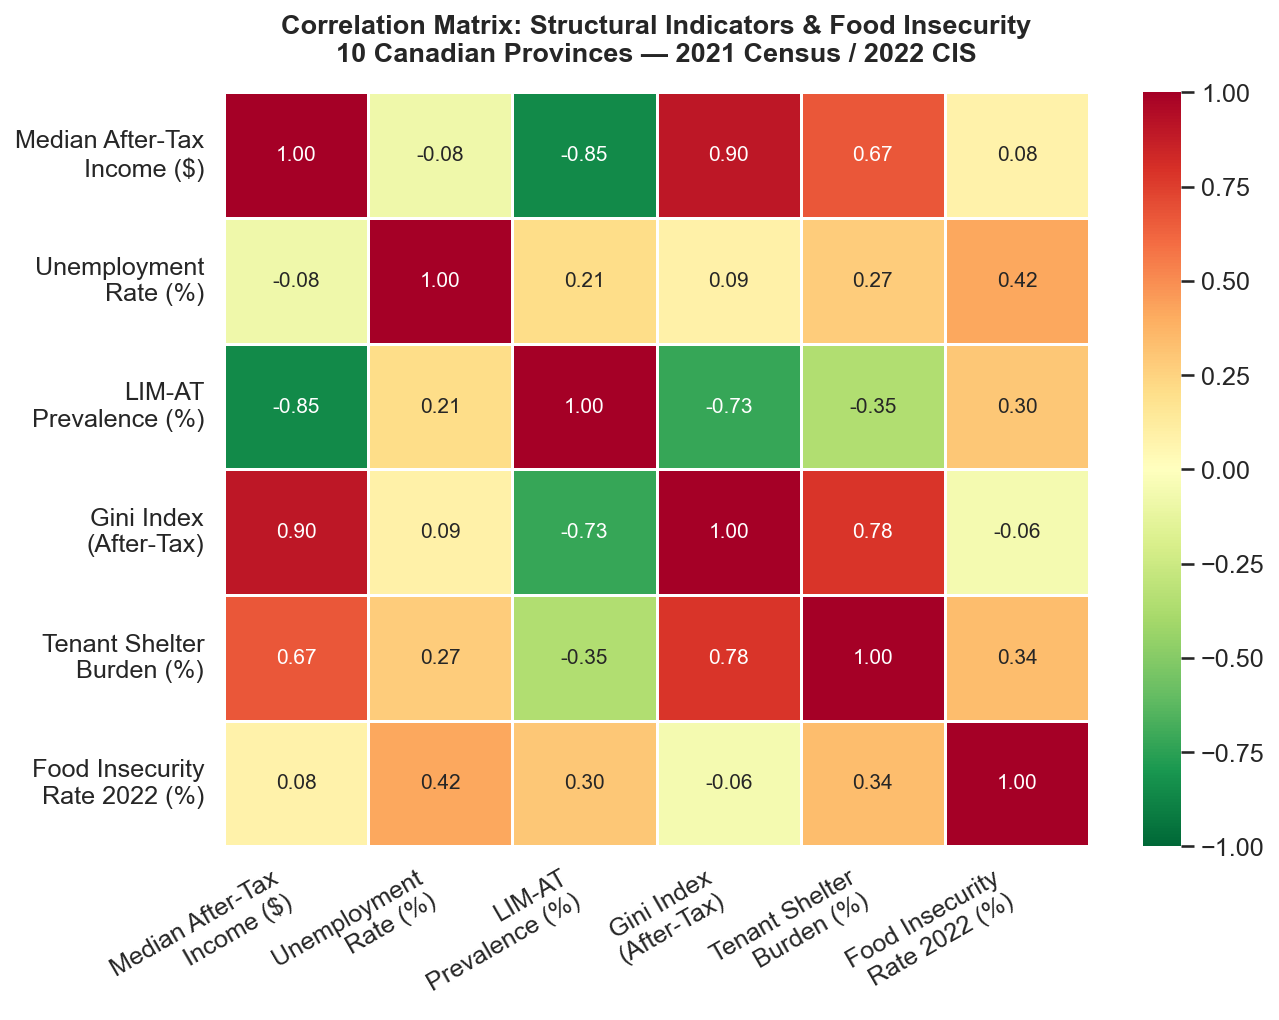

✅ Saved: export/correlation_heatmap.png


In [23]:
# DESCRIPTIVE STATISTICS 

# ── Step 1: Summary statistics for provinces only (exclude Canada aggregate) ─
prov_only = master_prov[~master_prov['is_canada']].copy()

analysis_cols = [
    'median_aftertax_income', 'unemployment_rate', 'lim_at_pct',
    'gini_aftertax', 'tenant_shelter_burden_pct', 'fi_2022_pct'
]

desc = prov_only[analysis_cols].describe().T
desc.columns = ['N', 'Mean', 'Std Dev', 'Min', '25%', 'Median', '75%', 'Max']
desc['Mean'] = desc['Mean'].round(2)
desc['Std Dev'] = desc['Std Dev'].round(2)

print("── Descriptive Statistics (10 Provinces, 2021/2022) ──")
print(desc.to_string())

# Step 2: Correlation matrix with food insecurity
# Pearson correlation: measures linear association between -1 and +1
# Values close to +1 = strong positive relationship
# Values close to -1 = strong negative relationship
corr_matrix = prov_only[analysis_cols].corr(method='pearson')

# Step 3: Plot the heatmap
fig, ax = plt.subplots(figsize=(9, 7))

# Create readable labels for the heatmap axes
labels = {
    'median_aftertax_income': 'Median After-Tax\nIncome ($)',
    'unemployment_rate': 'Unemployment\nRate (%)',
    'lim_at_pct': 'LIM-AT\nPrevalence (%)',
    'gini_aftertax': 'Gini Index\n(After-Tax)',
    'tenant_shelter_burden_pct': 'Tenant Shelter\nBurden (%)',
    'fi_2022_pct': 'Food Insecurity\nRate 2022 (%)'
}
corr_renamed = corr_matrix.rename(index=labels, columns=labels)

sns.heatmap(
    corr_renamed,
    annot=True,           # Show correlation values inside cells
    fmt='.2f',            # 2 decimal places
    cmap='RdYlGn_r',      # Red = high correlation, Green = low
    vmin=-1, vmax=1,      # Fix colour scale to -1 to +1
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 10}
)

ax.set_title(
    'Correlation Matrix: Structural Indicators & Food Insecurity\n'
    '10 Canadian Provinces — 2021 Census / 2022 CIS',
    fontsize=13, fontweight='bold', pad=15
)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('export/correlation_heatmap.png')
plt.show()
print("✅ Saved: export/correlation_heatmap.png")

### RQ1: The Income-Insecurity Paradox

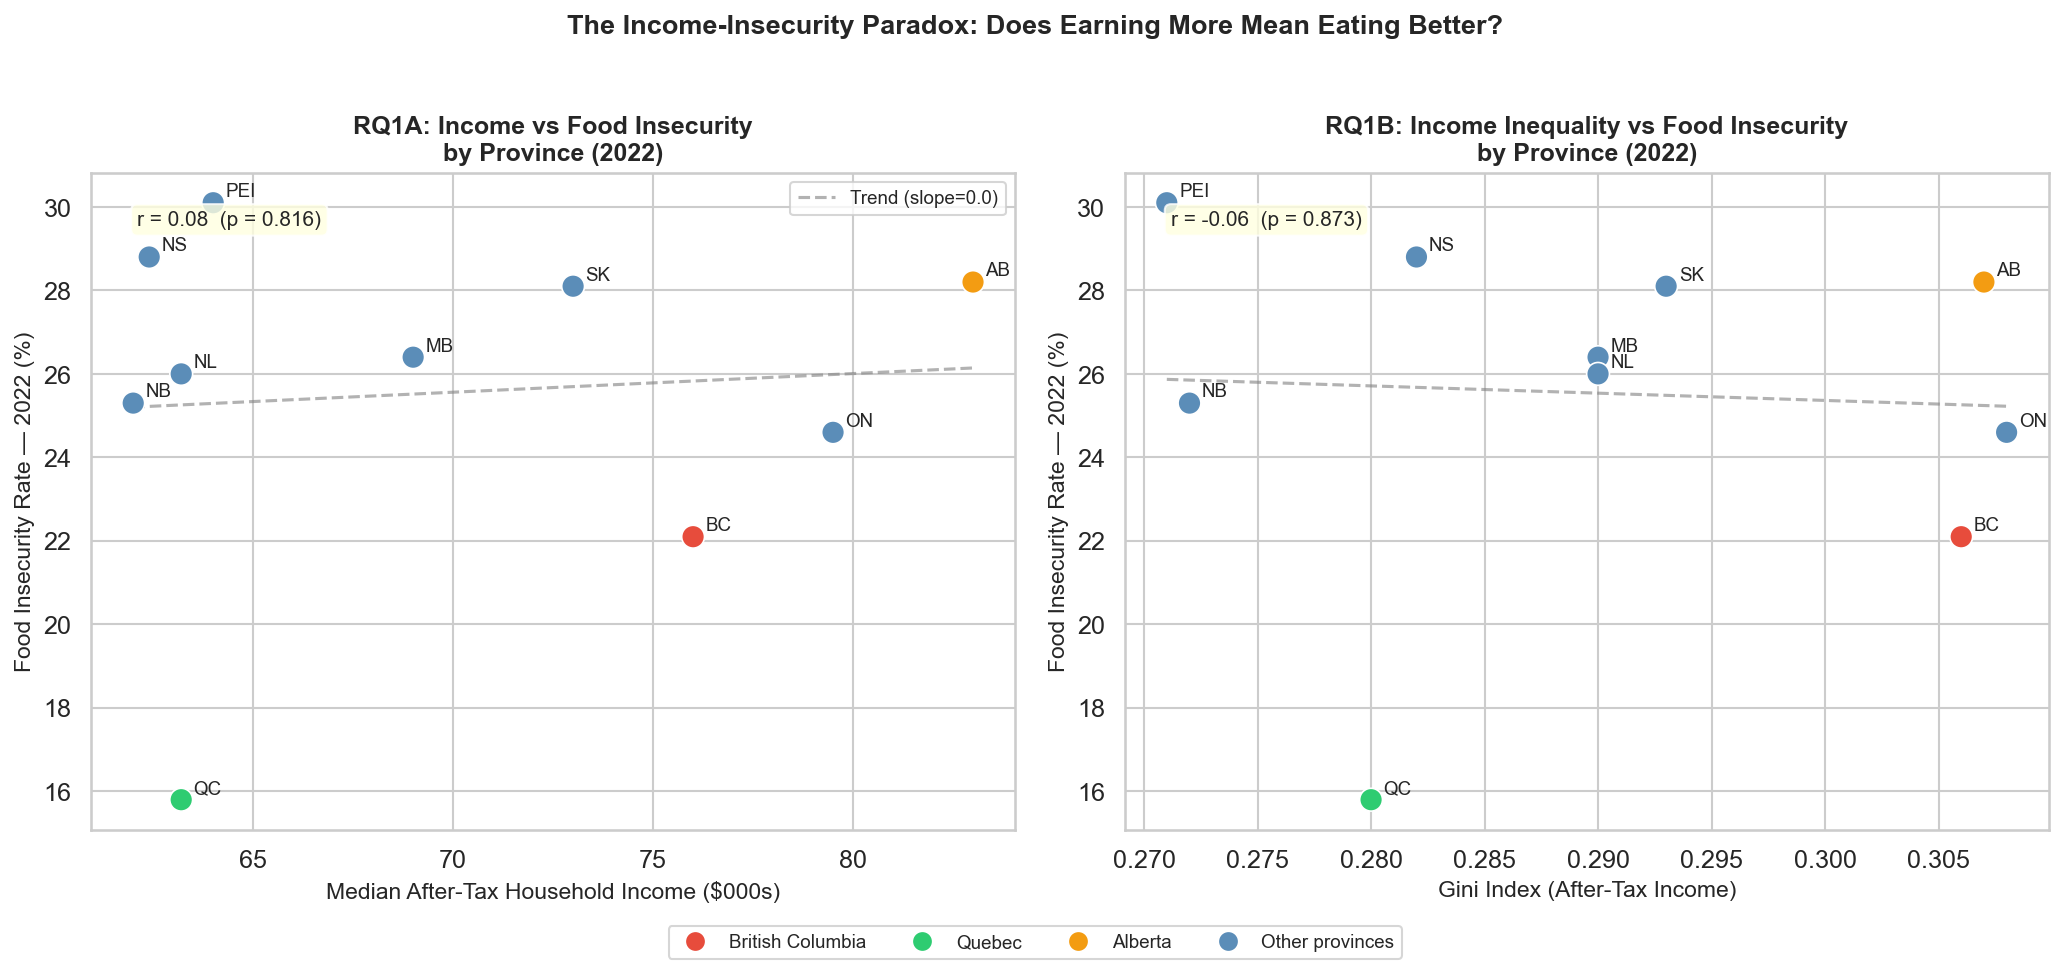

✅ Saved: export/rq1_income_insecurity_paradox.png


In [24]:
# RQ1 — THE INCOME-INSECURITY PARADOX 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot A: Income vs Food Insecurity
ax = axes[0]

# Colour BC and QC distinctly — they are the key outliers
colors = prov_only['province'].map({
    'British Columbia': '#e74c3c',   # Red for BC
    'Quebec': '#2ecc71',             # Green for QC
    'Alberta': '#f39c12'             # Orange for AB
}).fillna('#5b8db8')                 # Blue for all others

ax.scatter(
    prov_only['income_k'],
    prov_only['fi_2022_pct'],
    c=colors, s=120, zorder=3, edgecolors='white', linewidths=0.8
)

# Add a linear trend line using numpy polyfit
# polyfit(x, y, 1) fits a degree-1 (straight line) polynomial
m, b = np.polyfit(prov_only['income_k'], prov_only['fi_2022_pct'], 1)
x_line = np.linspace(prov_only['income_k'].min(), prov_only['income_k'].max(), 100)
ax.plot(x_line, m * x_line + b, '--', color='grey', alpha=0.6, linewidth=1.5,
        label=f'Trend (slope={m:.1f})')

# Label every province abbreviation on the chart
for _, row in prov_only.iterrows():
    ax.annotate(
        row['abbrev'],
        (row['income_k'], row['fi_2022_pct']),
        textcoords='offset points', xytext=(6, 3), fontsize=9
    )

# Calculate and display Pearson r and p-value in the chart
r, p = stats.pearsonr(prov_only['income_k'], prov_only['fi_2022_pct'])
ax.text(0.05, 0.92, f'r = {r:.2f}  (p = {p:.3f})',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax.set_xlabel('Median After-Tax Household Income ($000s)', fontsize=11)
ax.set_ylabel('Food Insecurity Rate — 2022 (%)', fontsize=11)
ax.set_title('RQ1A: Income vs Food Insecurity\nby Province (2022)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Plot B: Gini vs Food Insecurity
ax = axes[1]

ax.scatter(
    prov_only['gini_aftertax'],
    prov_only['fi_2022_pct'],
    c=colors, s=120, zorder=3, edgecolors='white', linewidths=0.8
)

m2, b2 = np.polyfit(prov_only['gini_aftertax'], prov_only['fi_2022_pct'], 1)
x_line2 = np.linspace(prov_only['gini_aftertax'].min(), prov_only['gini_aftertax'].max(), 100)
ax.plot(x_line2, m2 * x_line2 + b2, '--', color='grey', alpha=0.6, linewidth=1.5)

for _, row in prov_only.iterrows():
    ax.annotate(
        row['abbrev'],
        (row['gini_aftertax'], row['fi_2022_pct']),
        textcoords='offset points', xytext=(6, 3), fontsize=9
    )

r2, p2 = stats.pearsonr(prov_only['gini_aftertax'], prov_only['fi_2022_pct'])
ax.text(0.05, 0.92, f'r = {r2:.2f}  (p = {p2:.3f})',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax.set_xlabel('Gini Index (After-Tax Income)', fontsize=11)
ax.set_ylabel('Food Insecurity Rate — 2022 (%)', fontsize=11)
ax.set_title('RQ1B: Income Inequality vs Food Insecurity\nby Province (2022)',
             fontsize=12, fontweight='bold')

# Legend for province colours
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c',
           markersize=10, label='British Columbia'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71',
           markersize=10, label='Quebec'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#f39c12',
           markersize=10, label='Alberta'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#5b8db8',
           markersize=10, label='Other provinces'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.suptitle(
    'The Income-Insecurity Paradox: Does Earning More Mean Eating Better?',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('export/rq1_income_insecurity_paradox.png')
plt.show()
print("✅ Saved: export/rq1_income_insecurity_paradox.png")

 ### RQ2: The Quebec Exception

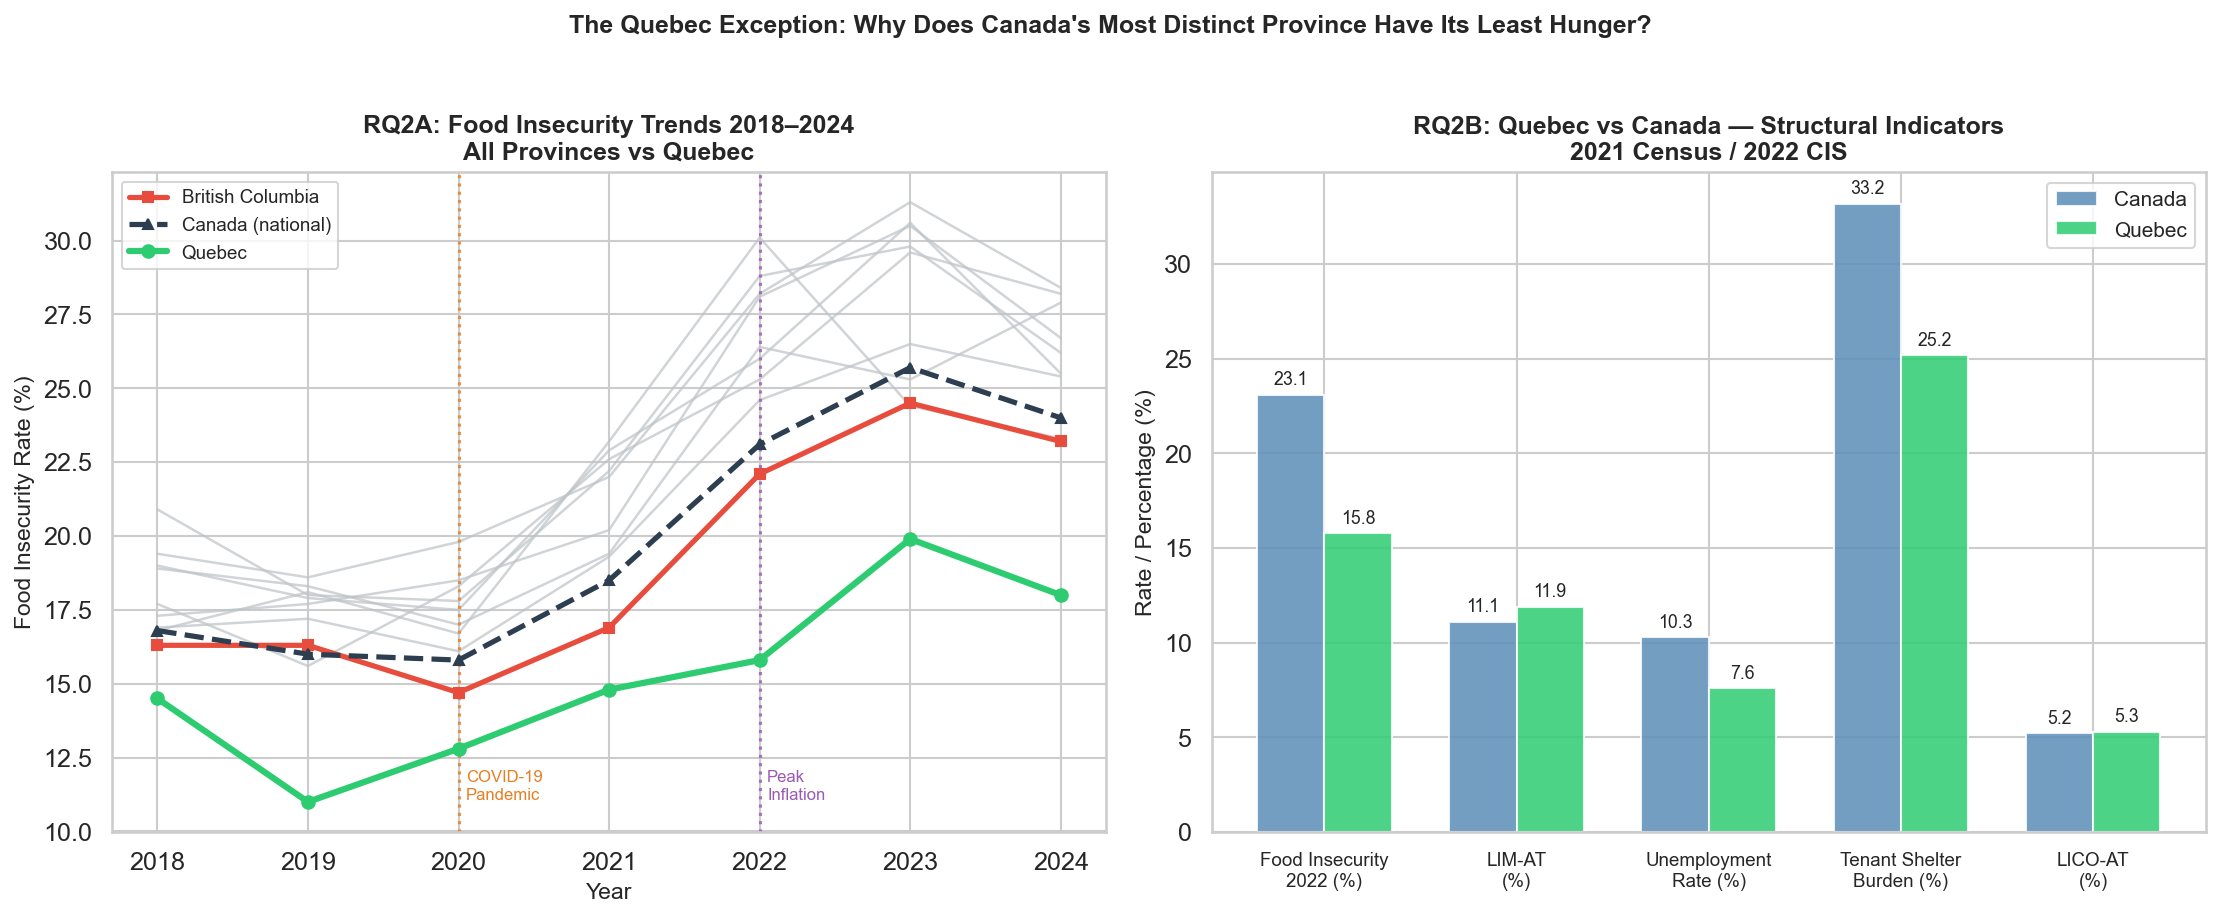

✅ Saved: export/rq2_quebec_exception.png


In [25]:
# RQ2 — THE QUEBEC EXCEPTION 

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: 7-Year Trend Lines by Province
ax = axes[0]

# Colour Quebec and BC distinctly, grey out all other provinces
for province, group in fi_trend.groupby('province'):
    if province == 'Quebec':
        ax.plot(group['year'], group['food_insecurity_pct'],
                color='#2ecc71', linewidth=3, marker='o', markersize=6,
                label='Quebec', zorder=5)
    elif province == 'British Columbia':
        ax.plot(group['year'], group['food_insecurity_pct'],
                color='#e74c3c', linewidth=2.5, marker='s', markersize=5,
                label='British Columbia', zorder=4)
    elif province == 'Canada':
        ax.plot(group['year'], group['food_insecurity_pct'],
                color='#2c3e50', linewidth=2.5, linestyle='--', marker='^',
                markersize=5, label='Canada (national)', zorder=4)
    else:
        ax.plot(group['year'], group['food_insecurity_pct'],
                color='#bdc3c7', linewidth=1.2, alpha=0.7)

# Add vertical markers for key events
ax.axvline(2020, color='#e67e22', linestyle=':', linewidth=1.5, alpha=0.8)
ax.axvline(2022, color='#9b59b6', linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(2020.05, ax.get_ylim()[0] + 1, 'COVID-19\nPandemic', fontsize=8,
        color='#e67e22', va='bottom')
ax.text(2022.05, ax.get_ylim()[0] + 1, 'Peak\nInflation', fontsize=8,
        color='#9b59b6', va='bottom')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Food Insecurity Rate (%)', fontsize=11)
ax.set_title('RQ2A: Food Insecurity Trends 2018–2024\nAll Provinces vs Quebec',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(2018, 2025))
ax.legend(fontsize=9, loc='upper left')

# Plot B: Quebec vs Canada — Structural Indicator Comparison 
ax = axes[1]

# Select Quebec and Canada rows, then compare on key structural indicators
compare_vars = {
    'Food Insecurity\n2022 (%)': 'fi_2022_pct',
    'LIM-AT\n(%)': 'lim_at_pct',
    'Unemployment\nRate (%)': 'unemployment_rate',
    'Tenant Shelter\nBurden (%)': 'tenant_shelter_burden_pct',
    'LICO-AT\n(%)': 'lico_at_pct'
}

# Get Quebec and Canada rows from the master table (master_prov includes Canada)
qc_row = master_prov[master_prov['province'] == 'Quebec'].iloc[0]
can_row = master_prov[master_prov['province'] == 'Canada'].iloc[0]

labels_bar = list(compare_vars.keys())
qc_vals = [qc_row[v] for v in compare_vars.values()]
can_vals = [can_row[v] for v in compare_vars.values()]

x = np.arange(len(labels_bar))
width = 0.35

bars1 = ax.bar(x - width/2, can_vals, width, label='Canada', color='#5b8db8', alpha=0.85)
bars2 = ax.bar(x + width/2, qc_vals, width, label='Quebec', color='#2ecc71', alpha=0.85)

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8.5)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(labels_bar, fontsize=9)
ax.set_ylabel('Rate / Percentage (%)', fontsize=11)
ax.set_title('RQ2B: Quebec vs Canada — Structural Indicators\n2021 Census / 2022 CIS',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.suptitle(
    "The Quebec Exception: Why Does Canada's Most Distinct Province Have Its Least Hunger?",
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('export/rq2_quebec_exception.png')
plt.show()
print("✅ Saved: export/rq2_quebec_exception.png")

### RQ3: Unemployment vs Food Insecurity

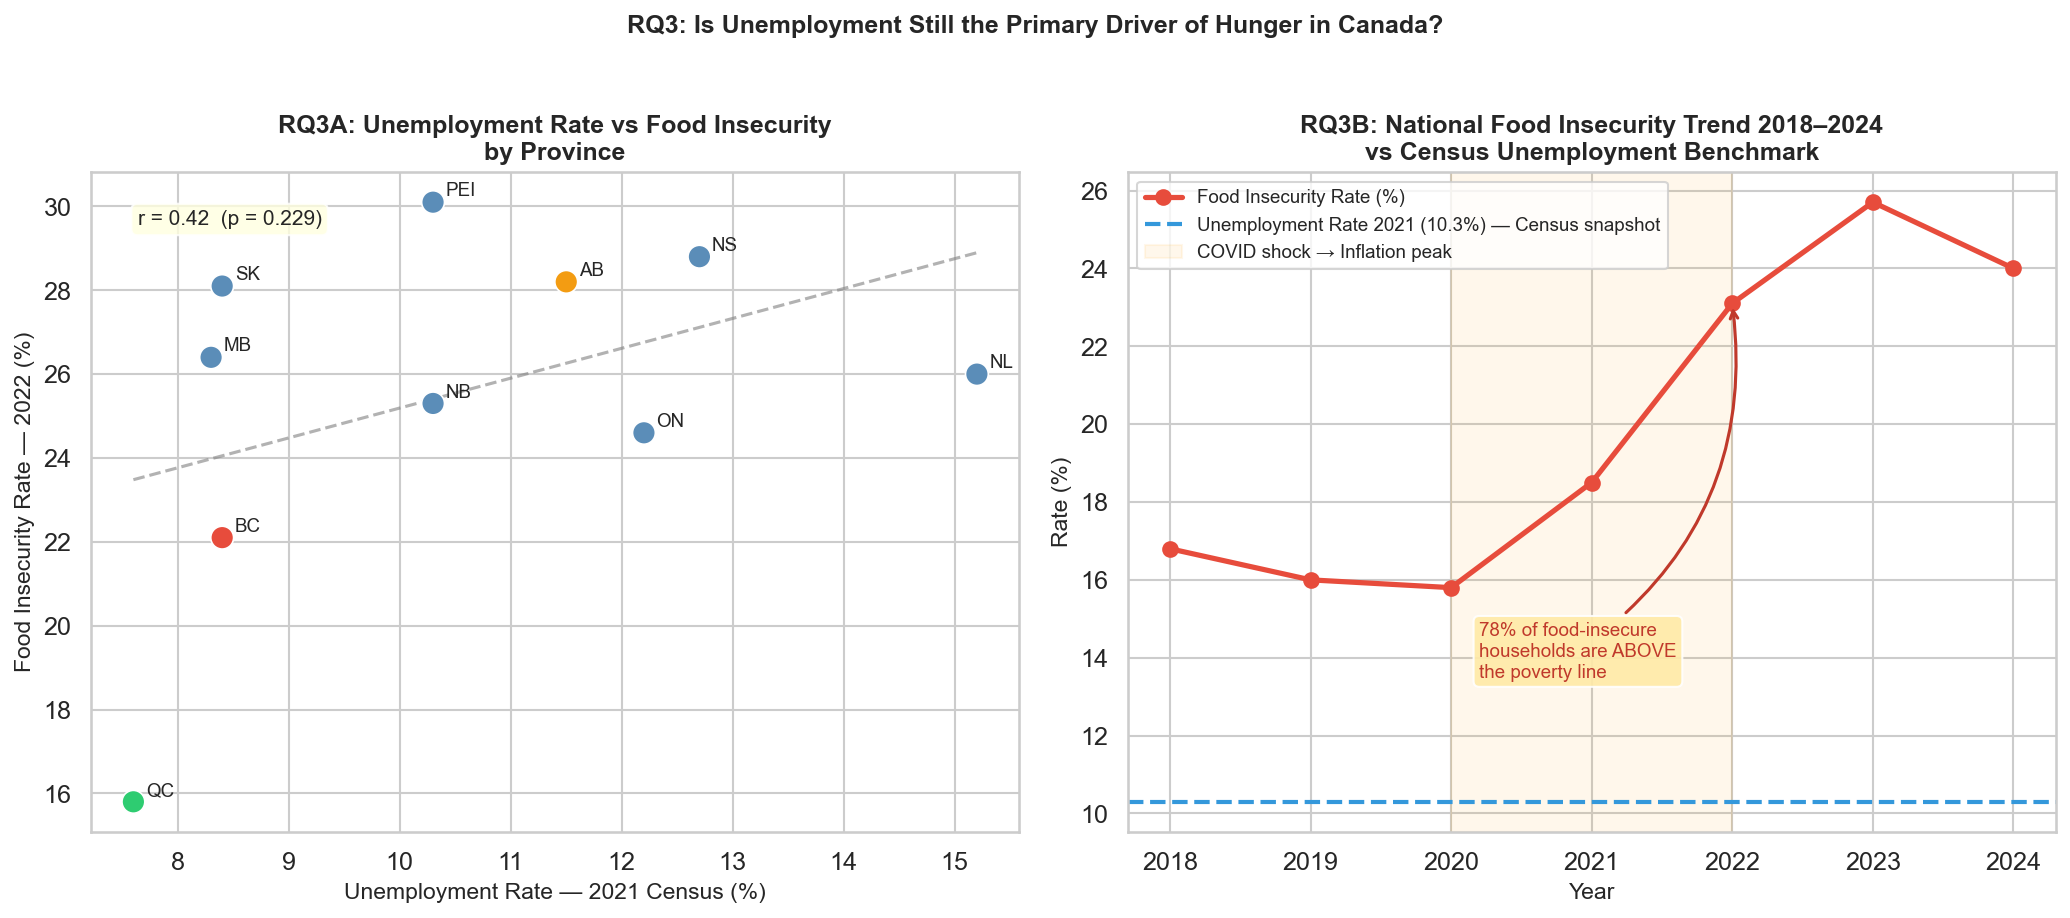

✅ Saved: export/rq3_unemployment_food_insecurity.png


In [26]:
# RQ3 — UNEMPLOYMENT vs FOOD INSECURITY

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot A: Scatter — Unemployment Rate vs Food Insecurity 2022
ax = axes[0]

ax.scatter(
    prov_only['unemployment_rate'],
    prov_only['fi_2022_pct'],
    c=colors, s=120, zorder=3, edgecolors='white', linewidths=0.8
)

# Trend line
m3, b3 = np.polyfit(prov_only['unemployment_rate'], prov_only['fi_2022_pct'], 1)
x_line3 = np.linspace(
    prov_only['unemployment_rate'].min(),
    prov_only['unemployment_rate'].max(), 100
)
ax.plot(x_line3, m3 * x_line3 + b3, '--', color='grey', alpha=0.6, linewidth=1.5)

for _, row in prov_only.iterrows():
    ax.annotate(
        row['abbrev'],
        (row['unemployment_rate'], row['fi_2022_pct']),
        textcoords='offset points', xytext=(6, 3), fontsize=9
    )

r3, p3 = stats.pearsonr(prov_only['unemployment_rate'], prov_only['fi_2022_pct'])
ax.text(0.05, 0.92, f'r = {r3:.2f}  (p = {p3:.3f})',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax.set_xlabel('Unemployment Rate — 2021 Census (%)', fontsize=11)
ax.set_ylabel('Food Insecurity Rate — 2022 (%)', fontsize=11)
ax.set_title('RQ3A: Unemployment Rate vs Food Insecurity\nby Province', fontsize=12,
             fontweight='bold')

# Plot B: Dual-axis trend — Unemployment & Food Insecurity over time
# Uses only Canada-level data since provincial unemployment trend needs 
# a separate CANSIM table. National trends still show the structural story.
ax2 = axes[1]

canada_fi = fi_trend[fi_trend['province'] == 'Canada'].copy()

# Unemployment rate from 2021 Census is a single point (10.3%)
# We annotate it on the chart rather than drawing a false trend line
ax2.plot(canada_fi['year'], canada_fi['food_insecurity_pct'],
         color='#e74c3c', linewidth=2.5, marker='o', markersize=7,
         label='Food Insecurity Rate (%)')

ax2.axhline(y=10.3, color='#3498db', linestyle='--', linewidth=2,
            label='Unemployment Rate 2021 (10.3%) — Census snapshot')

# Shade the COVID-to-inflation period
ax2.axvspan(2020, 2022, alpha=0.08, color='orange',
            label='COVID shock → Inflation peak')

ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Rate (%)', fontsize=11)
ax2.set_title('RQ3B: National Food Insecurity Trend 2018–2024\nvs Census Unemployment Benchmark',
              fontsize=12, fontweight='bold')
ax2.set_xticks(range(2018, 2025))
ax2.legend(fontsize=9)

# Add annotation explaining the paradox
ax2.annotate(
    '78% of food-insecure\nhouseholds are ABOVE\nthe poverty line',
    xy=(2022, canada_fi[canada_fi['year'] == 2022]['food_insecurity_pct'].values[0]),
    xytext=(2020.2, 13.5),          # Moved to bottom-right area, well below trend
    fontsize=9, color='#c0392b',
    arrowprops=dict(
        arrowstyle='->',
        color='#c0392b',
        lw=1.5,
        connectionstyle='arc3,rad=0.3'   # Curved arrow avoids crossing the line
    ),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffeaa7', alpha=0.9)
)


plt.suptitle(
    "RQ3: Is Unemployment Still the Primary Driver of Hunger in Canada?",
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('export/rq3_unemployment_food_insecurity.png')
plt.show()
print("✅ Saved: export/rq3_unemployment_food_insecurity.png")

### RQ4: Provincial Vulnerability Index

── Provincial Vulnerability Index Rankings ──
                 province  vulnerability_index  fi_2022_pct
                  Ontario             0.674130         24.6
         British Columbia             0.616023         22.1
                 Manitoba             0.613548         26.4
Newfoundland and Labrador             0.613309         26.0
              Nova Scotia             0.604532         28.8
                  Alberta             0.499790         28.2
             Saskatchewan             0.422745         28.1
     Prince Edward Island             0.332428         30.1
            New Brunswick             0.293241         25.3
                   Quebec             0.261726         15.8


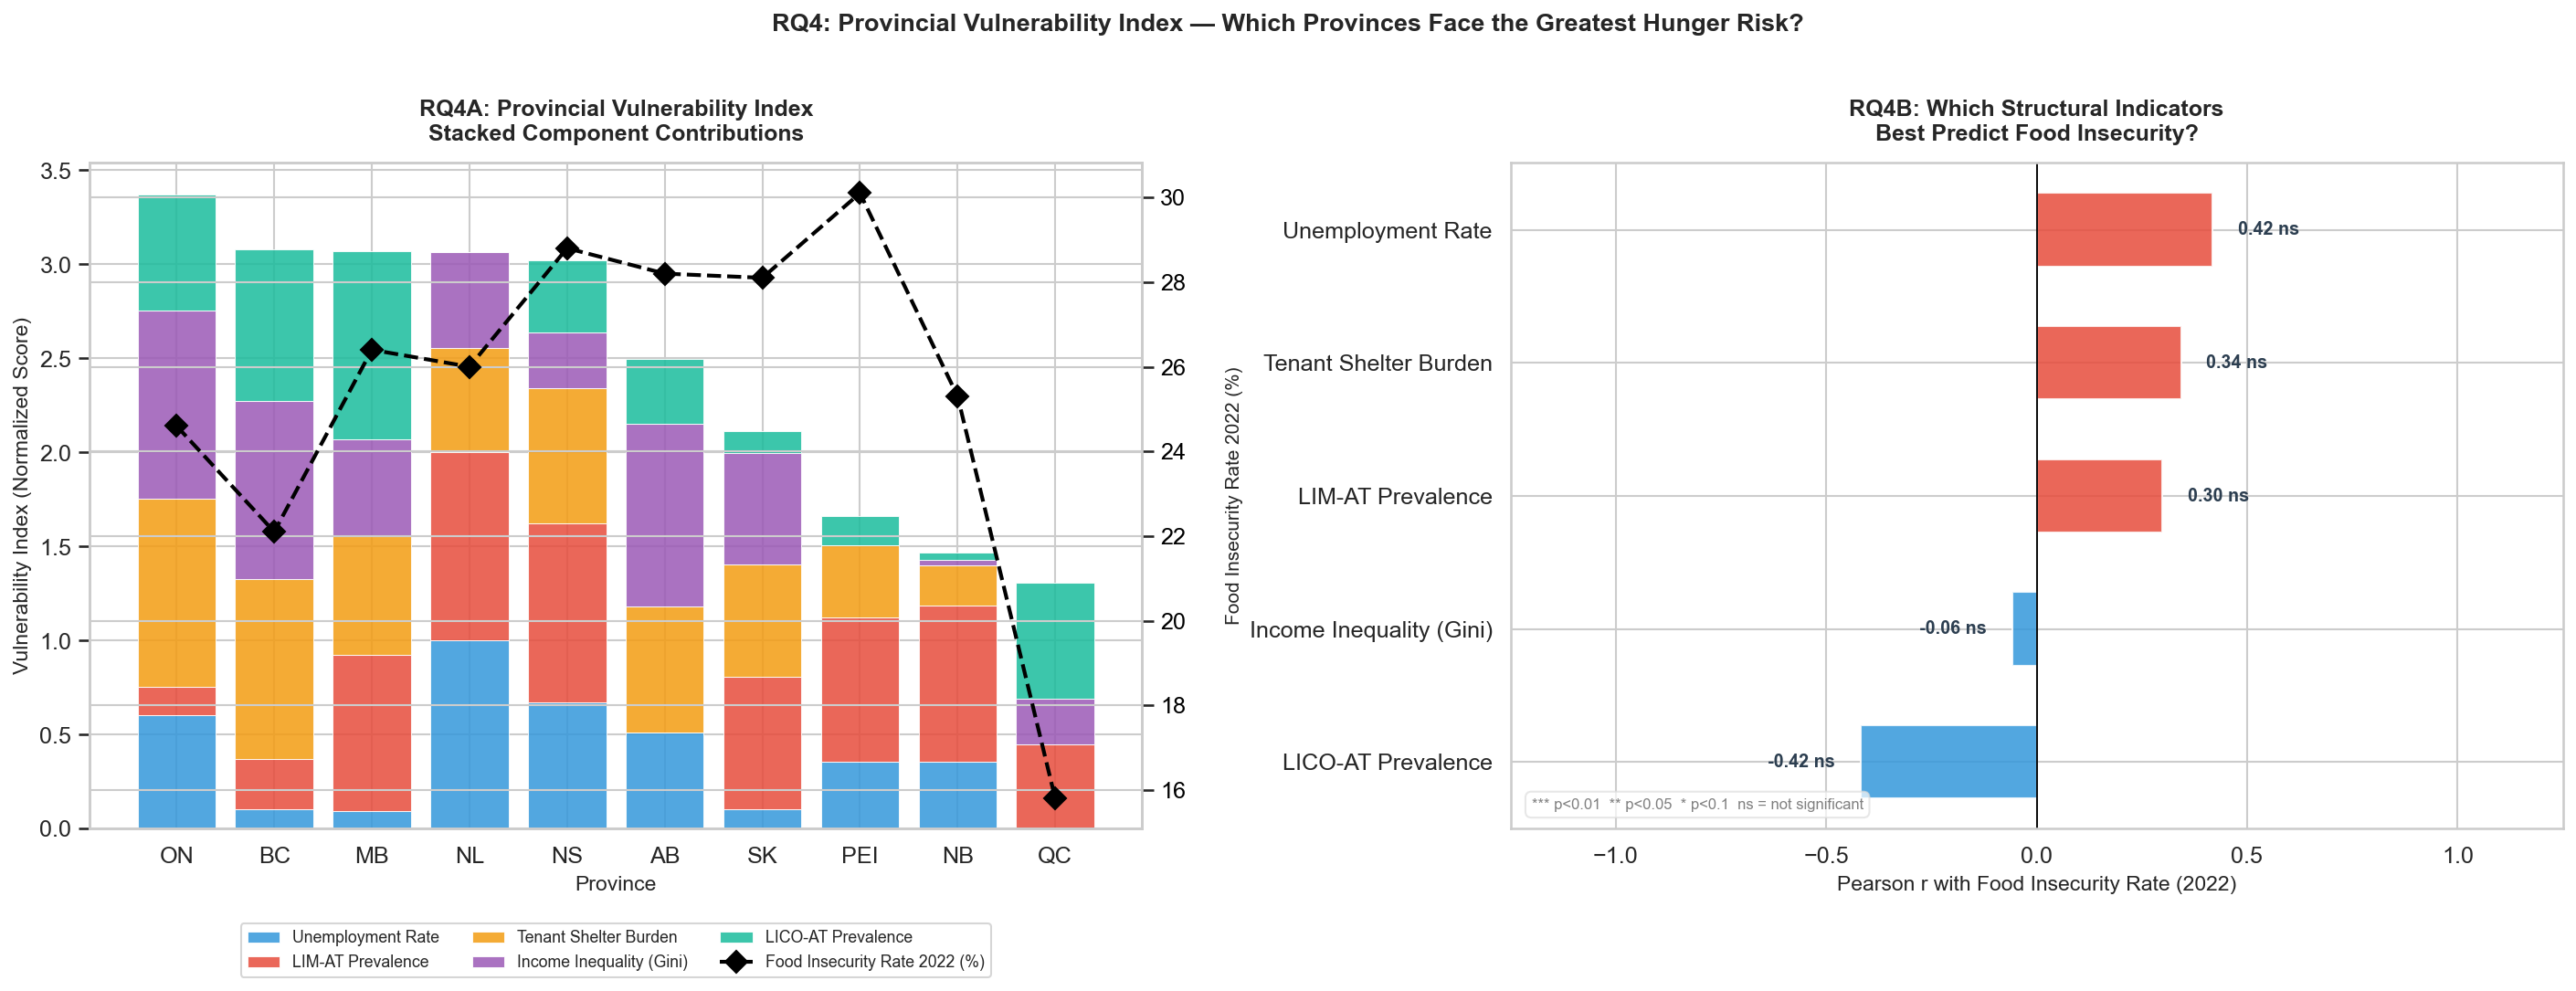

✅ Saved: export/rq4_vulnerability_index.png


In [27]:
# RQ4 — PROVINCIAL VULNERABILITY INDEX 

# Step 1: Select the 5 index components 
# Food insecurity is the OUTCOME — excluded from the index itself
index_vars = {
    'unemployment_rate':       'Unemployment Rate',
    'lim_at_pct':              'LIM-AT Prevalence',
    'tenant_shelter_burden_pct': 'Tenant Shelter Burden',
    'gini_aftertax':           'Income Inequality (Gini)',
    'lico_at_pct':             'LICO-AT Prevalence'
}

idx_df = prov_only[['province', 'abbrev', 'fi_2022_pct'] +
                    list(index_vars.keys())].copy()

# Step 2: Min-Max normalization 
# Rescales each indicator to 0–1 regardless of original units
# Score of 1 = most vulnerable | Score of 0 = least vulnerable
for col in index_vars.keys():
    col_min = idx_df[col].min()
    col_max = idx_df[col].max()
    idx_df[f'{col}_norm'] = (idx_df[col] - col_min) / (col_max - col_min)

# Step 3: Compute composite score 
# Equal-weighted average of the 5 normalized component scores
norm_cols      = [f'{c}_norm' for c in index_vars.keys()]
component_labels = list(index_vars.values())

idx_df['vulnerability_index'] = idx_df[norm_cols].mean(axis=1)
idx_df = idx_df.sort_values('vulnerability_index', ascending=False).reset_index(drop=True)

print("── Provincial Vulnerability Index Rankings ──")
print(idx_df[['province', 'vulnerability_index', 'fi_2022_pct']].to_string(index=False))

# Step 4: Build figure
# Wider + taller to give both subplots breathing room
fig, axes = plt.subplots(1, 2, figsize=(19, 7))

provinces_sorted  = idx_df['abbrev'].tolist()
component_colors  = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

# ─────────────────────────────────────────────────────────────────────────────
# PLOT A — Stacked bar chart with secondary food insecurity line
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[0]
bottom = np.zeros(len(idx_df))

for i, (col, label) in enumerate(zip(norm_cols, component_labels)):
    ax.bar(
        provinces_sorted,
        idx_df[col].values,
        bottom=bottom,
        label=label,
        color=component_colors[i],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.5
    )
    bottom += idx_df[col].values

# Secondary y-axis — food insecurity rate overlay line
ax2_twin = ax.twinx()
ax2_twin.plot(
    provinces_sorted, idx_df['fi_2022_pct'].values,
    'D--', color='black', linewidth=2, markersize=8,
    label='Food Insecurity Rate 2022 (%)', zorder=5
)
ax2_twin.set_ylabel('Food Insecurity Rate 2022 (%)', fontsize=10, labelpad=15)
ax2_twin.tick_params(axis='y', labelcolor='black')

# Ensure right y-axis label is not clipped
ax2_twin.yaxis.set_label_coords(1.08, 0.5)

ax.set_xlabel('Province', fontsize=11)
ax.set_ylabel('Vulnerability Index (Normalized Score)', fontsize=11)
ax.set_title('RQ4A: Provincial Vulnerability Index\nStacked Component Contributions',
             fontsize=12, fontweight='bold', pad=12)

# Legend placed BELOW the chart — eliminates all overlap 
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.13),  # Pulls legend below the x-axis
    ncol=3,
    fontsize=8.5,
    frameon=True,
    fancybox=True,
    edgecolor='#cccccc'
)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT B — Horizontal bar: correlation of each component with food insecurity
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[1]

correlations = {}
for col, label in index_vars.items():
    r_val, p_val = stats.pearsonr(idx_df[col], idx_df['fi_2022_pct'])
    correlations[label] = {'r': r_val, 'p': p_val}

corr_df    = pd.DataFrame(correlations).T.sort_values('r', ascending=True)
bar_colors = ['#e74c3c' if r > 0 else '#3498db' for r in corr_df['r']]

ax.barh(
    corr_df.index,
    corr_df['r'],
    color=bar_colors,
    alpha=0.85,
    edgecolor='white',
    height=0.55          # Slightly narrower bars = more whitespace for labels
)

# Value labels: always outside the bar, never overlapping
for i, (idx_label, row) in enumerate(corr_df.iterrows()):
    star = ('***' if row['p'] < 0.01 else
            '**'  if row['p'] < 0.05 else
            '*'   if row['p'] < 0.1  else 'ns')
    if row['r'] >= 0:
        x_pos = row['r'] + 0.06   # Right of positive bar
        ha    = 'left'
    else:
        x_pos = row['r'] - 0.06   # Left of negative bar
        ha    = 'right'
    ax.text(
        x_pos, i,
        f'{row["r"]:.2f} {star}',
        va='center', ha=ha,
        fontsize=9.5, color='#2c3e50',
        fontweight='bold'
    )

ax.axvline(0, color='black', linewidth=0.9)
ax.set_xlabel('Pearson r with Food Insecurity Rate (2022)', fontsize=11)
ax.set_title('RQ4B: Which Structural Indicators\nBest Predict Food Insecurity?',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(-1.25, 1.25)          # Extra room on both sides for labels

# Significance legend note — bottom left, inside plot
ax.text(
    0.02, 0.03,
    '*** p<0.01  ** p<0.05  * p<0.1  ns = not significant',
    transform=ax.transAxes,
    fontsize=8, color='grey',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='#dddddd',
              boxstyle='round,pad=0.4')
)

# Supertitle + layout
plt.suptitle(
    'RQ4: Provincial Vulnerability Index — Which Provinces Face the Greatest Hunger Risk?',
    fontsize=13, fontweight='bold', y=1.01
)

# subplots_adjust adds bottom margin so the below-axis legend is not clipped
plt.tight_layout()
plt.subplots_adjust(bottom=0.16, wspace=0.35)

plt.savefig('export/rq4_vulnerability_index.png', bbox_inches='tight')
plt.show()
print("✅ Saved: export/rq4_vulnerability_index.png")

### City Spotlight & Demographic Equity

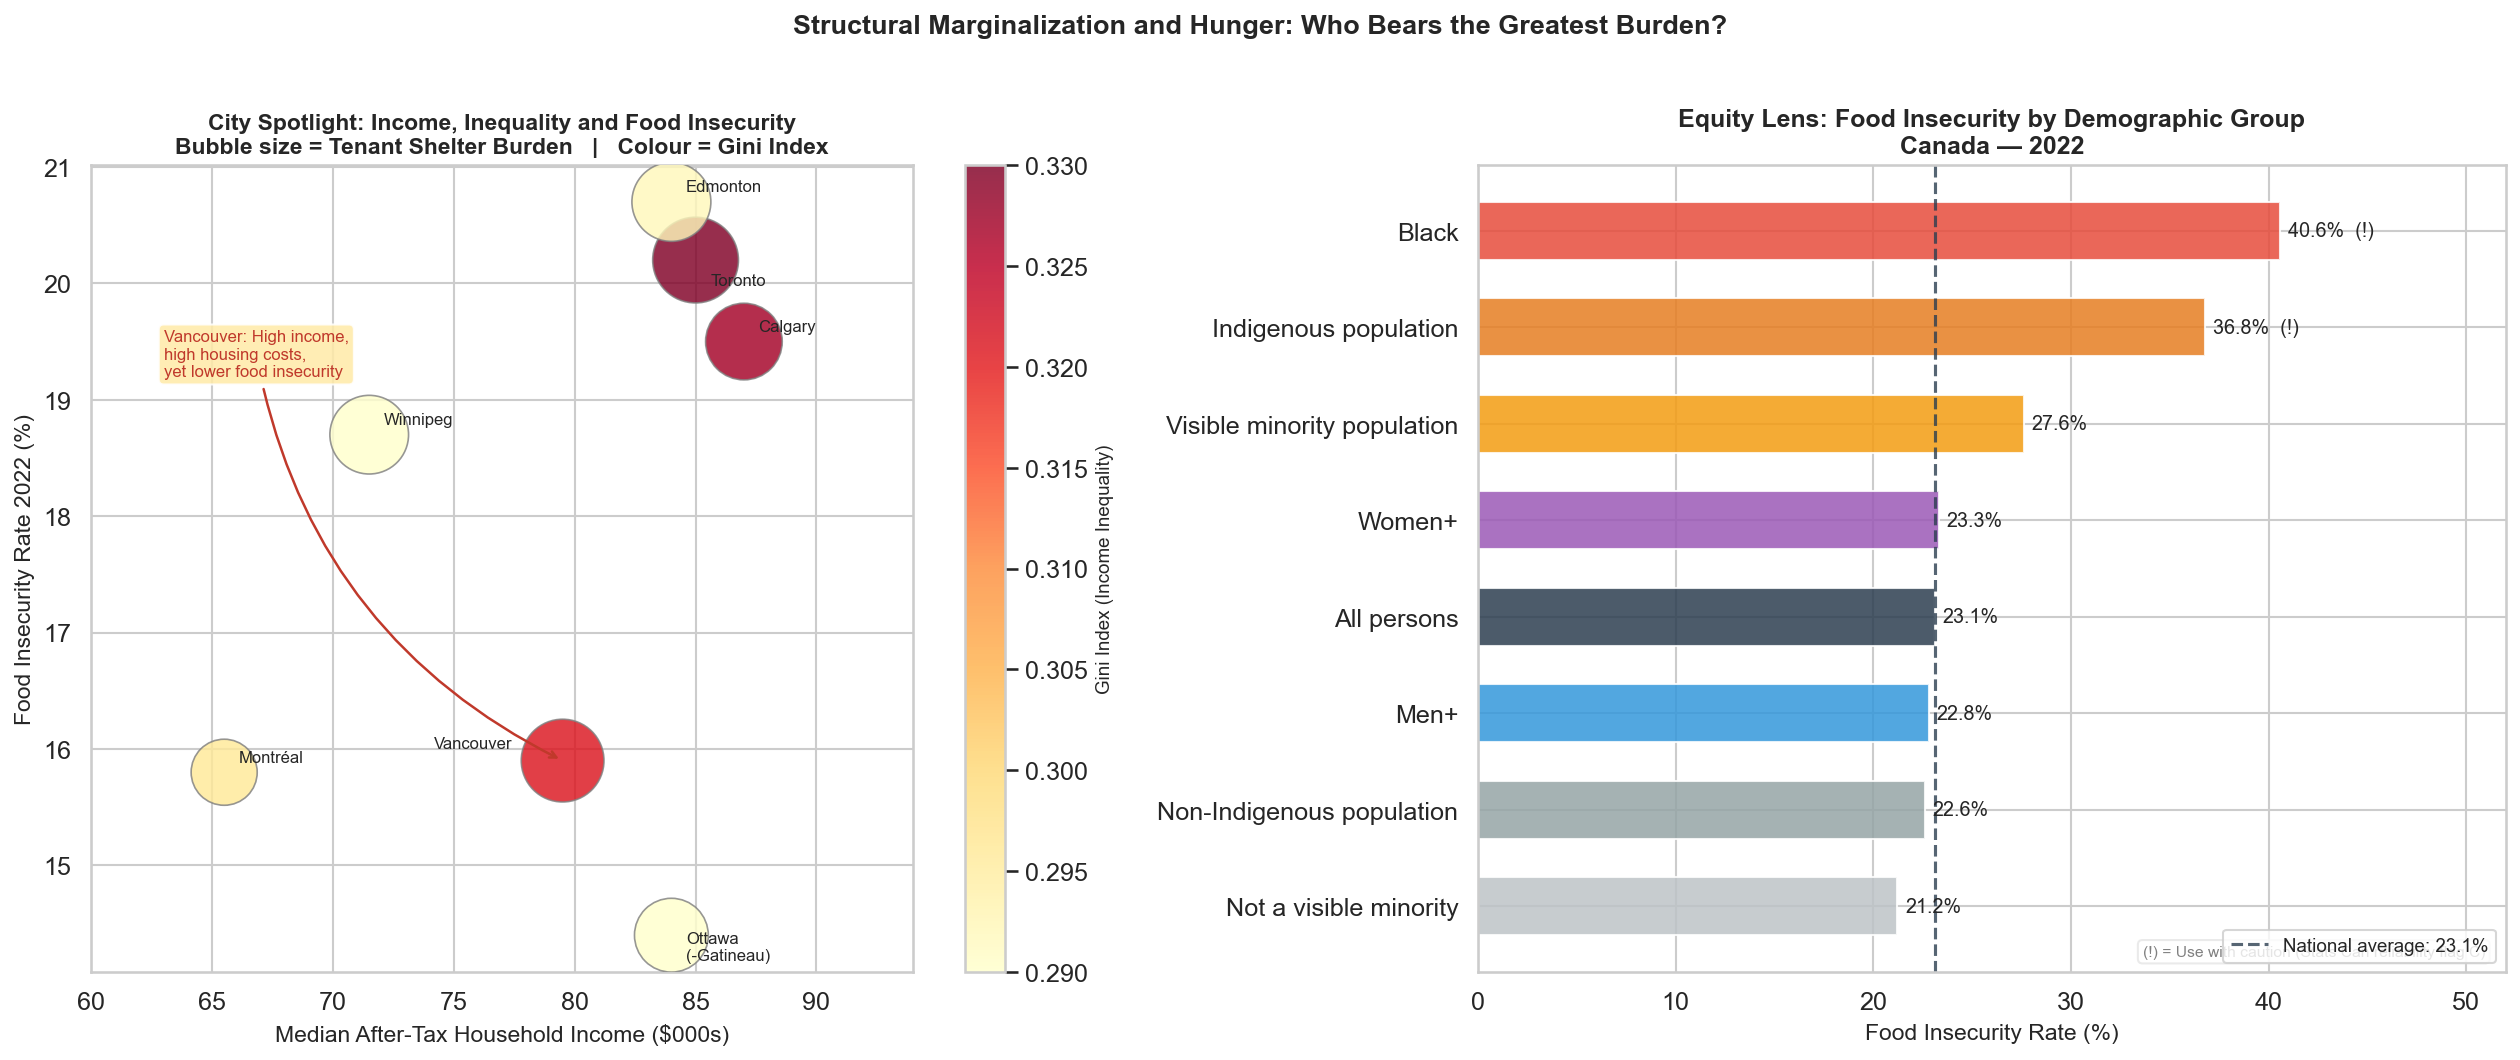

Saved: export/city_spotlight_equity.png


In [29]:
# CITY SPOTLIGHT AND DEMOGRAPHIC EQUITY

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# ============================================================
# PLOT A: CMA Spotlight — 7 Major Cities
# Food insecurity rates from Stats Can article (Uppal 2023)
# Reference year: 2022 (2021 Canadian Income Survey)
# ============================================================

cma_fi_2022 = {
    'Ottawa - Gatineau': 14.4,
    'Vancouver':         15.9,
    'Montréal':          15.8,
    'Winnipeg':          18.7,
    'Calgary':           19.5,
    'Toronto':           20.2,
    'Edmonton':          20.7
}

# Pull census indicators for these 7 cities from the CMA dataset
cma_spotlight = census_cma[census_cma['city'].isin(cma_fi_2022.keys())].copy()
cma_spotlight['fi_2022_pct'] = cma_spotlight['city'].map(cma_fi_2022)
cma_spotlight['income_k']    = cma_spotlight['median_aftertax_income'] / 1000
cma_spotlight = cma_spotlight.sort_values('fi_2022_pct').reset_index(drop=True)

ax = axes[0]

# Bubble chart: x = income | y = food insecurity
# Bubble SIZE encodes tenant shelter burden (third data dimension)
# Bubble COLOUR encodes Gini index (fourth data dimension)
# Scaling formula reduced to prevent large cities dominating the canvas
bubble_sizes = (cma_spotlight['tenant_shelter_burden_pct'] * 5) ** 1.4

scatter = ax.scatter(
    cma_spotlight['income_k'],
    cma_spotlight['fi_2022_pct'],
    s=bubble_sizes,
    c=cma_spotlight['gini_aftertax'],
    cmap='YlOrRd',
    alpha=0.82,
    edgecolors='grey',
    linewidths=0.8,
    zorder=3
)

# Colorbar for Gini index
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Gini Index (Income Inequality)', fontsize=9)

# Custom offsets per city to prevent label overlap
# Positive xytext = move right and up | Negative = move left and down
label_offsets = {
    'Edmonton':          (7,   5),
    'Toronto':           (7, -12),
    'Calgary':           (7,   5),
    'Vancouver':         (-62,  6),
    'Winnipeg':          (7,   5),
    'Montréal':          (7,   5),
    'Ottawa - Gatineau': (7, -12),
}

for _, row in cma_spotlight.iterrows():
    city_label = (row['city']
                  .replace(' - Gatineau', '\n(-Gatineau)')
                  .replace(' - Mission',  '\n(-Mission)'))
    offset = label_offsets.get(row['city'], (7, 5))
    ax.annotate(
        city_label,
        (row['income_k'], row['fi_2022_pct']),
        textcoords='offset points',
        xytext=offset,
        fontsize=8,
        zorder=6
    )

# Vancouver callout annotation
ax.annotate(
    'Vancouver: High income,\nhigh housing costs,\nyet lower food insecurity',
    xy=(79.5, 15.9),
    xytext=(63, 19.2),
    fontsize=8,
    color='#c0392b',
    arrowprops=dict(
        arrowstyle='->',
        color='#c0392b',
        lw=1.2,
        connectionstyle='arc3,rad=0.25'
    ),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffeaa7', alpha=0.85)
)

# X-axis starts at 60 to give Montréal breathing room on the left
ax.set_xlim(60, cma_spotlight['income_k'].max() + 7)
ax.set_xlabel('Median After-Tax Household Income ($000s)', fontsize=11)
ax.set_ylabel('Food Insecurity Rate 2022 (%)', fontsize=11)
ax.set_title(
    'City Spotlight: Income, Inequality and Food Insecurity\n'
    'Bubble size = Tenant Shelter Burden   |   Colour = Gini Index',
    fontsize=11, fontweight='bold'
)

# ============================================================
# PLOT B: Demographic Disparities — Canada 2022
# ============================================================

ax = axes[1]

# Colour each demographic group distinctly
# Equity-relevant groups (Black, Indigenous) get warm high-contrast colours
demo_colors_map = {
    'Black':                    '#e74c3c',
    'Indigenous population':    '#e67e22',
    'Visible minority population': '#f39c12',
    'Women+':                   '#9b59b6',
    'All persons':              '#2c3e50',
    'Men+':                     '#3498db',
    'Non-Indigenous population':'#95a5a6',
    'Not a visible minority':   '#bdc3c7'
}

fi_demo['color']  = fi_demo['group'].map(demo_colors_map).fillna('#bdc3c7')
fi_demo_sorted    = fi_demo.sort_values('fi_pct', ascending=True).reset_index(drop=True)

bars = ax.barh(
    fi_demo_sorted['group'],
    fi_demo_sorted['fi_pct'],
    color=fi_demo_sorted['color'],
    alpha=0.85,
    edgecolor='white',
    height=0.6
)

# Value labels outside bars
# (!) replaces unicode warning symbol to avoid encoding issues on Windows
for bar, (_, row) in zip(bars, fi_demo_sorted.iterrows()):
    flag = '(!)' if row['reliability'] in ['C', 'D'] else ''
    label_text = f"  {row['fi_pct']:.1f}%  {flag}".strip()
    ax.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        label_text,
        va='center',
        fontsize=9.5
    )

# National average reference line
nat_avg = fi_demo[fi_demo['group'] == 'All persons']['fi_pct'].values[0]
ax.axvline(
    nat_avg,
    color='#2c3e50',
    linestyle='--',
    linewidth=1.5,
    alpha=0.8,
    label=f'National average: {nat_avg:.1f}%'
)

ax.set_xlabel('Food Insecurity Rate (%)', fontsize=11)
ax.set_xlim(0, 52)
ax.set_title(
    'Equity Lens: Food Insecurity by Demographic Group\nCanada — 2022',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9, loc='lower right')

# Reliability footnote using plain text symbol
ax.text(
    0.98, 0.02,
    '(!) = Use with caution (Stats Can reliability flag C)',
    transform=ax.transAxes,
    fontsize=7.5, ha='right', color='grey',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='#dddddd',
              boxstyle='round,pad=0.3')
)

# ============================================================
# SHARED TITLE AND LAYOUT
# ============================================================

plt.suptitle(
    'Structural Marginalization and Hunger: Who Bears the Greatest Burden?',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.subplots_adjust(wspace=0.35)
plt.savefig('export/city_spotlight_equity.png', bbox_inches='tight')
plt.show()
print("Saved: export/city_spotlight_equity.png")

### Export Cleaned Datasets

In [30]:
# CELL 12: EXPORT CLEANED DATASETS

# Master provincial table (census + food insecurity merged)
master_prov.to_csv('export/master_provincial.csv', index=False)
print("✅ Saved: export/master_provincial.csv")

# CMA census indicators (wide format, 41 cities)
census_cma.to_csv('export/census_cma_clean.csv', index=False)
print("✅ Saved: export/census_cma_clean.csv")

# Food insecurity 7-year trend panel
fi_trend.to_csv('export/food_insecurity_trend.csv', index=False)
print("✅ Saved: export/food_insecurity_trend.csv")

# Food insecurity severity breakdown 2022
fi_severity.to_csv('export/food_insecurity_severity_2022.csv', index=False)
print("✅ Saved: export/food_insecurity_severity_2022.csv")

# Vulnerability index rankings
idx_df[['province', 'abbrev', 'vulnerability_index', 'fi_2022_pct'] + 
       list(index_vars.keys())].to_csv('export/vulnerability_index.csv', index=False)
print("✅ Saved: export/vulnerability_index.csv")

print("\n── All exports complete. Your export/ folder now contains:")
for f in sorted(os.listdir('export')):
    size_kb = os.path.getsize(f'export/{f}') / 1024
    print(f"   {f}  ({size_kb:.1f} KB)")

✅ Saved: export/master_provincial.csv
✅ Saved: export/census_cma_clean.csv
✅ Saved: export/food_insecurity_trend.csv
✅ Saved: export/food_insecurity_severity_2022.csv
✅ Saved: export/vulnerability_index.csv

── All exports complete. Your export/ folder now contains:
   census_cma_clean.csv  (2.0 KB)
   city_spotlight_equity.png  (233.7 KB)
   correlation_heatmap.png  (189.8 KB)
   food_insecurity_severity_2022.csv  (0.3 KB)
   food_insecurity_trend.csv  (2.0 KB)
   master_provincial.csv  (1.1 KB)
   rq1_income_insecurity_paradox.png  (131.8 KB)
   rq2_quebec_exception.png  (271.9 KB)
   rq3_unemployment_food_insecurity.png  (175.7 KB)
   rq4_vulnerability_index.png  (215.6 KB)
   vulnerability_index.csv  (0.8 KB)
